# Load Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [7]:
## There are two datasets which i am using


In [8]:
reviews_path = r"C:\\gfg python\\Review.jsonl"
meta_path = r"C:\\gfg python\\meta.jsonl"

reviews_df = pd.read_json(reviews_path, lines=True)
meta_df = pd.read_json(meta_path, lines=True)

In [11]:
print(reviews_df.shape)
print(meta_df.shape)


(701528, 10)
(112590, 14)


In [14]:
# Analyze Review Dataset

In [16]:
reviews_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [18]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             701528 non-null  int64         
 1   title              701528 non-null  object        
 2   text               701528 non-null  object        
 3   images             701528 non-null  object        
 4   asin               701528 non-null  object        
 5   parent_asin        701528 non-null  object        
 6   user_id            701528 non-null  object        
 7   timestamp          701528 non-null  datetime64[ns]
 8   helpful_vote       701528 non-null  int64         
 9   verified_purchase  701528 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 48.8+ MB


In [20]:
reviews_df.shape

(701528, 10)

# Columns

In [23]:
for i in reviews_df.columns:
    print(i)

rating
title
text
images
asin
parent_asin
user_id
timestamp
helpful_vote
verified_purchase


## Checking Null Values

### No Null values in our dataset

In [26]:
reviews_df.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

## Checking Duplicate Values

### Before Checking duplicate values,I have to delete images columns,Other wise code will generate error 'unhashable type: 'list'

In [30]:
reviews_df = reviews_df.drop(columns=["images"])

### Now checking duplicates

In [33]:
 reviews_df.columns

Index(['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

# Checking Duplicates

In [36]:
reviews_df.duplicated().sum()

7275

## There are 7353 duplicates in Reviews_data So I am going to remove them

In [38]:
reviews_df = reviews_df.drop_duplicates()

### In 'TITLE" Column there are also duplicates values but we can't remove them because they are very short and repeat of them is common and if remove them then we loose 317859 rows which make our data unstable.

In [41]:
reviews_df["title"].duplicated().sum()

317859

### Now,Checking Dupliacte values

In [45]:
reviews_df.duplicated().sum()

0

## No Duplicate Values

## Drop User_id Unnecessary Column

In [48]:
reviews_df = reviews_df.drop(columns=["user_id","helpful_vote", "verified_purchase","asin"])


## # Remove very short reviews (e.g., less than 5 characters)

In [52]:
reviews_df = reviews_df[reviews_df['text'].str.len() >= 5].reset_index(drop=True)

### Sorting column Orders

In [55]:
reviews_df = reviews_df[["parent_asin", "rating", "title", "text", "timestamp"]]

In [57]:
reviews_df.head()

,parent_asin,rating,title,text,timestamp
0,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,2020-05-05 14:08:48.923
1,B081TJ8YS3,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",2020-05-04 18:10:55.070
2,B097R46CSY,5,Yes!,"Smells good, feels great!",2020-05-16 21:41:06.052
3,B09JS339BZ,1,Synthetic feeling,Felt synthetic,2022-01-28 18:13:50.220
4,B08BZ63GMJ,5,A+,Love it,2020-12-30 10:02:43.534


In [59]:
reviews_df.shape

(686873, 5)

In [61]:
reviews_df.to_csv("review_data.csv", index=False, encoding="utf-8")

In [62]:
df=pd.read_csv('review_data.csv')

In [63]:
df.head()

,parent_asin,rating,title,text,timestamp
0,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,2020-05-05 14:08:48.923
1,B081TJ8YS3,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",2020-05-04 18:10:55.070
2,B097R46CSY,5,Yes!,"Smells good, feels great!",2020-05-16 21:41:06.052
3,B09JS339BZ,1,Synthetic feeling,Felt synthetic,2022-01-28 18:13:50.220
4,B08BZ63GMJ,5,A+,Love it,2020-12-30 10:02:43.534


#  Meta_Data File

In [65]:
meta_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN


In [66]:
# Columns to drop from metadata
columns_to_drop = [
    "features",
    "description",
    "images",
    "videos",
    "categories",
    "details",
    "bought_together",
    "price"
]

# Drop them safely (ignore if column doesn't exist)
meta_df = meta_df.drop(columns=columns_to_drop, errors="ignore")

# Check remaining columns
meta_df.head()

,main_category,title,average_rating,rating_number,store,parent_asin
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,Howard Products,B01CUPMQZE
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,Yes To,B076WQZGPM
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,Levine Health Products,B000B658RI
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,Cherioll,B088FKY3VD
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,Precision,B07NGFDN6G


In [67]:
meta_df.shape

(112590, 6)

In [69]:
meta_df.describe()

,average_rating,rating_number
count,112590.000000,112590.000000
mean,3.883488,50.541345
std,0.874384,310.992502
min,1.000000,1.000000
25%,3.400000,3.000000
50%,4.000000,9.000000
75%,4.500000,28.000000
max,5.000000,30206.000000


## Checking NULL VALUES

In [71]:
meta_df.isnull().sum()

main_category         0
title                 0
average_rating        0
rating_number         0
store             11331
parent_asin           0
dtype: int64

## Fill It with Unknown

In [80]:
meta_df['store'] = meta_df['store'].fillna("Unknown")

In [82]:
meta_df['store'].value_counts()

store
Unknown              11470
Bath & Body Works      481
WILLBOND               388
Hairro                 381
Generic                369
                     ...  
Lingon                   1
STAUB                    1
Lambda Beauty            1
YUATCYA                  1
DVIO                     1
Name: count, Length: 30765, dtype: int64

In [84]:
meta_df = meta_df.rename(columns={
    "rating_number": "Rating_number(Sales_Proxy)"
})

In [86]:
meta_df.head()

,main_category,title,average_rating,Rating_number(Sales_Proxy),store,parent_asin
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,Howard Products,B01CUPMQZE
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,Yes To,B076WQZGPM
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,Levine Health Products,B000B658RI
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,Cherioll,B088FKY3VD
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,Precision,B07NGFDN6G


## I want a dataset with atleast sales_proxy of 5,beacuse if i consider less than that then their will be no valuable insights we get from it

## Keep Only Products With Sales ≥ 5

In [90]:
# Keep only rows where sales_proxy is at least 5
meta_df = meta_df[meta_df['Rating_number(Sales_Proxy)'] >= 5]

# Reset index after filtering
meta_df = meta_df.reset_index(drop=True)

# Check the result
meta_df['Rating_number(Sales_Proxy)'].describe()

count    76603.000000
mean        73.223921
std        374.890152
min          5.000000
25%          9.000000
50%         18.000000
75%         45.000000
max      30206.000000
Name: Rating_number(Sales_Proxy), dtype: float64

In [92]:
meta_df.head()

,main_category,title,average_rating,Rating_number(Sales_Proxy),store,parent_asin
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,Howard Products,B01CUPMQZE
1,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,Levine Health Products,B000B658RI
2,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,Cherioll,B088FKY3VD
3,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,Precision,B07NGFDN6G
4,All Beauty,Lurrose 100Pcs Full Cover Fake Toenails Artifi...,3.7,35,Lurrose,B07G9GWFSM


## Keep only reviews for products that exist in metadata

In [95]:
valid_asins = set(meta_df['parent_asin'].unique())
reviews_df = reviews_df[reviews_df['parent_asin'].isin(valid_asins)].reset_index(drop=True)

In [97]:
len(valid_asins)

76603

##  Clean the review text (for sentiment/NLP)

In [100]:
import re
import string

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

reviews_df['text'] = reviews_df['text'].apply(clean_text)

In [101]:
reviews_df.head()

,parent_asin,rating,title,text,timestamp
0,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,this spray is really nice it smells really goo...,2020-05-05 14:08:48.923
1,B081TJ8YS3,4,Works great but smells a little weird.,this product does what i need it to do i just ...,2020-05-04 18:10:55.070
2,B097R46CSY,5,Yes!,smells good feels great,2020-05-16 21:41:06.052
3,B08BZ63GMJ,5,A+,love it,2020-12-30 10:02:43.534
4,B00R8DXL44,4,Pretty Color,the polish was quiet thick and did not apply s...,2020-08-27 22:30:08.138


### Sentiment analysis (VADER)

In [105]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer


sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    return sia.polarity_scores(text)['compound']

reviews_df['sentiment_score'] = reviews_df['text'].apply(get_sentiment_score)

In [106]:
reviews_df.head()

,parent_asin,rating,title,text,timestamp,sentiment_score
0,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,this spray is really nice it smells really goo...,2020-05-05 14:08:48.923,0.8008
1,B081TJ8YS3,4,Works great but smells a little weird.,this product does what i need it to do i just ...,2020-05-04 18:10:55.070,0.7783
2,B097R46CSY,5,Yes!,smells good feels great,2020-05-16 21:41:06.052,0.7906
3,B08BZ63GMJ,5,A+,love it,2020-12-30 10:02:43.534,0.6369
4,B00R8DXL44,4,Pretty Color,the polish was quiet thick and did not apply s...,2020-08-27 22:30:08.138,0.0000


# Word2Vec embeddings from reviews

In [109]:
from gensim.models import Word2Vec
import numpy as np

# Prepare sentences
sentences = reviews_df['text'].apply(lambda x: x.split())

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# Function to get average Word2Vec vector per review
def get_w2v_vector(text):
    words = text.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vectors, axis=0)

# Apply to each review
reviews_df['w2v_vector'] = reviews_df['text'].apply(get_w2v_vector)


In [110]:
reviews_df.head()

,parent_asin,rating,title,text,timestamp,sentiment_score,w2v_vector
0,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,this spray is really nice it smells really goo...,2020-05-05 14:08:48.923,0.8008,"[0.12922207, 0.49552584, 0.23373872, -0.011339..."
1,B081TJ8YS3,4,Works great but smells a little weird.,this product does what i need it to do i just ...,2020-05-04 18:10:55.070,0.7783,"[-0.6936258, 0.02813256, 0.32307592, -0.074361..."
2,B097R46CSY,5,Yes!,smells good feels great,2020-05-16 21:41:06.052,0.7906,"[1.067443, 1.0179752, 0.15737711, -0.34929305,..."
3,B08BZ63GMJ,5,A+,love it,2020-12-30 10:02:43.534,0.6369,"[0.61338246, 1.1297896, -0.67010117, -0.550509..."
4,B00R8DXL44,4,Pretty Color,the polish was quiet thick and did not apply s...,2020-08-27 22:30:08.138,0.0000,"[0.40322676, -0.2820006, 0.14002496, -0.322690..."


 ## Aggregate review features to product level

In [114]:
# Expand Word2Vec vectors into separate columns
w2v_dim = w2v_model.vector_size
w2v_cols = [f'w2v_{i}' for i in range(w2v_dim)]

w2v_expanded = np.vstack(reviews_df['w2v_vector'].values)
w2v_df = (
    reviews_df[['parent_asin']].reset_index(drop=True)
    .join(
        # create DataFrame from vectors
        other = __import__('pandas').DataFrame(w2v_expanded, columns=w2v_cols),
        how='left'
    )
)

# Combine sentiment + rating + w2v for aggregation
reviews_for_agg = reviews_df[['parent_asin', 'rating', 'sentiment_score']].join(
    w2v_df[w2v_cols]
)

# Aggregate to product level
agg_dict = {
    'rating': ['mean', 'count'],
    'sentiment_score': ['mean', 'std']
}
for col in w2v_cols:
    agg_dict[col] = 'mean'

review_agg = reviews_for_agg.groupby('parent_asin').agg(agg_dict)

# Flatten columns
review_agg.columns = [
    '_'.join([c for c in col if c]) for col in review_agg.columns.values
]
review_agg = review_agg.reset_index()

# Rename key features
review_agg = review_agg.rename(columns={
    'rating_mean': 'avg_review_rating',
    'rating_count': 'num_reviews',
    'sentiment_score_mean': 'avg_sentiment',
    'sentiment_score_std': 'sentiment_std'
})

## Merge metadata + aggregated review features






In [116]:
final_df = meta_df.merge(review_agg, on='parent_asin', how='inner')
final_df['sentiment_std'] = final_df['sentiment_std'].fillna(0)

In [117]:
final_df

,main_category,title,average_rating,Rating_number(Sales_Proxy),store,parent_asin,avg_review_rating,num_reviews,avg_sentiment,sentiment_std,...,w2v_90_mean,w2v_91_mean,w2v_92_mean,w2v_93_mean,w2v_94_mean,w2v_95_mean,w2v_96_mean,w2v_97_mean,w2v_98_mean,w2v_99_mean
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,Howard Products,B01CUPMQZE,4.600000,5,0.797680,0.101119,...,0.064268,-0.258341,0.318637,-0.858966,-0.252055,0.245084,-0.217890,0.096986,0.445450,0.002645
1,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,Levine Health Products,B000B658RI,4.357143,14,0.325743,0.475050,...,0.454949,0.094337,0.949203,-0.524778,-0.391389,-0.367833,-0.362719,0.121273,-0.167280,-0.344562
2,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,Cherioll,B088FKY3VD,2.909091,11,0.229436,0.433933,...,0.417781,0.121162,0.694920,-0.148957,-0.440493,-0.089858,-0.385224,0.390350,-0.090561,-0.249848
3,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,Precision,B07NGFDN6G,5.000000,1,0.000000,0.000000,...,0.458582,-0.530960,0.722287,-0.332733,0.393404,0.639932,-0.846554,-0.424931,-0.012284,-0.282041
4,All Beauty,Lurrose 100Pcs Full Cover Fake Toenails Artifi...,3.7,35,Lurrose,B07G9GWFSM,2.000000,1,-0.077200,0.000000,...,0.241928,-0.066731,1.171811,-0.532919,-0.894347,0.189486,-0.683707,0.435581,-0.102697,-0.898784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76341,All Beauty,Lace Front Wigs Human Hair Pre Plucked 20Inch ...,3.7,14,HAOFAN,B08RSFV5QG,5.000000,1,0.840200,0.000000,...,0.251637,0.994384,0.679336,-0.297681,0.587850,0.142209,-0.371447,-0.319295,-0.111094,-1.403768
76342,All Beauty,Hulaidywig Women's Wigs Black Long Straight No...,3.6,8,Hulaidywig,B09KR9X2T9,1.000000,1,-0.153100,0.000000,...,-0.485921,-0.211889,0.043463,0.510679,-0.566545,0.080400,-0.390298,-0.917344,-0.046676,0.151510
76343,All Beauty,ELISHACOY Or.day Mild Sun Cream SPF50 PA++++ 5...,3.9,23,Elishacoy,B07RD3YSNR,5.000000,2,0.299700,0.423840,...,-1.260999,0.566527,0.718547,-0.897097,-0.773133,-0.971768,-0.328588,-1.463483,-0.056236,-1.147815
76344,All Beauty,[10Pack] Makeup Brushes Set Cosmetics Tools Ki...,4.3,5,RainMakers,B07HNP2NTF,5.000000,1,0.306400,0.000000,...,0.158364,-0.147570,0.393328,-1.216454,0.111810,-0.647834,0.375978,0.282430,0.167226,-0.266460


# EDA Visualisation¶

## 1. Average Rating Over Time

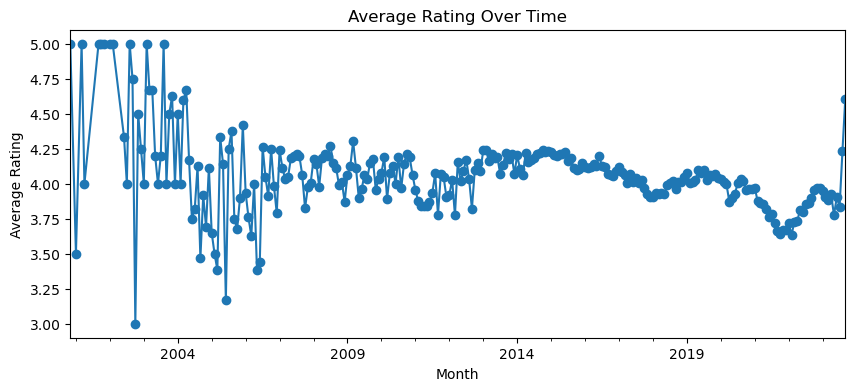

In [123]:
df1= reviews_df.copy()
df1['timestamp'] = pd.to_datetime(df1['timestamp'], errors='coerce')
df1["month"] = df1["timestamp"].dt.to_period("M")
plt.figure(figsize=(10,4))
df1.groupby("month")["rating"].mean().plot(kind="line", marker="o")
plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.show()

In [125]:
df1 = final_df.copy()

# 2.Outliers

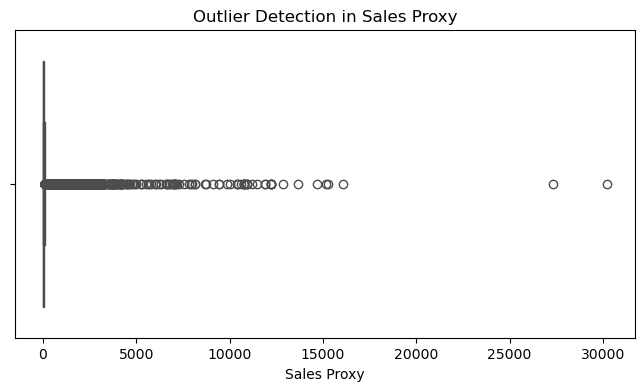

In [128]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df1['Rating_number(Sales_Proxy)'], color='orange')
plt.title("Outlier Detection in Sales Proxy")
plt.xlabel("Sales Proxy")
plt.show()

## No doubt there are outliers,But if i delete them then i lost my crucial data such as
## - Best‑selling products
## - Viral products
## - High‑visibility items
## - Products with thousands of reviews

# 3. Sentiment vs Sales Proxy

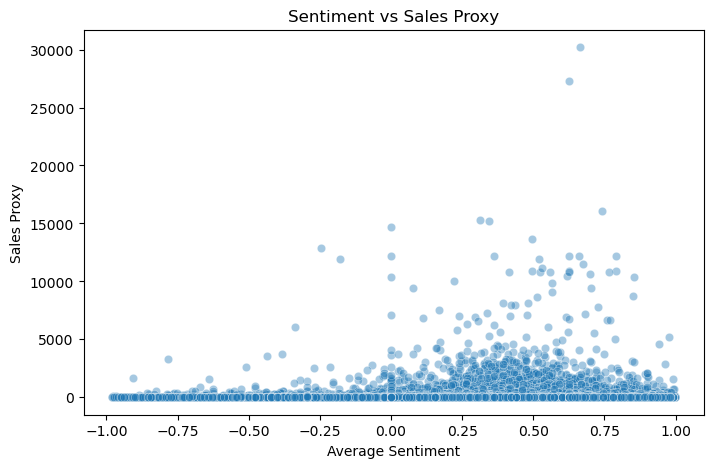

In [132]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df1['avg_sentiment'], 
                y=df1['Rating_number(Sales_Proxy)'], alpha=0.4)
plt.title("Sentiment vs Sales Proxy")
plt.xlabel("Average Sentiment")
plt.ylabel("Sales Proxy")
plt.show()

## - Negative sentiment = low sales
## - High‑selling products have moderate–high sentiment
## - Sentiment acts as a minimum quality threshold
## - Average sentiment products can still sell high if review volume is large

# 4. Average Rating vs Sales Proxy

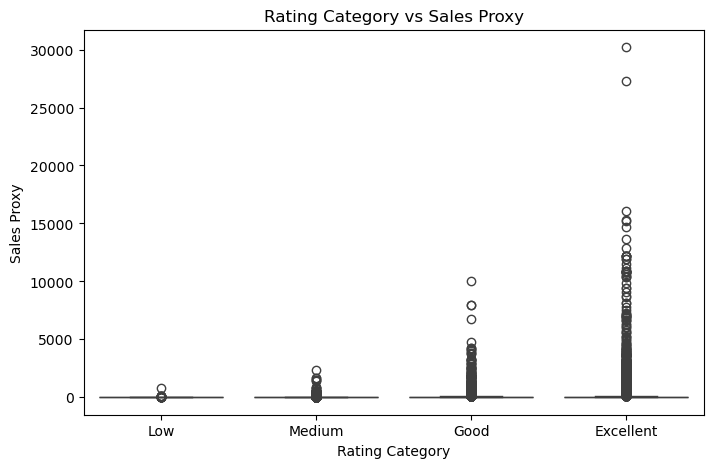

In [136]:
df1['rating_bin'] = pd.cut(
    df1['average_rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['Low', 'Medium', 'Good', 'Excellent']
)

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df1['rating_bin'],
    y=df1['Rating_number(Sales_Proxy)']
)
plt.title("Rating Category vs Sales Proxy")
plt.xlabel("Rating Category")
plt.ylabel("Sales Proxy")
plt.show()

## We can see that higher Sales rating Number has Higher sales Potential

# 5.Category‑wise Sales Distribution

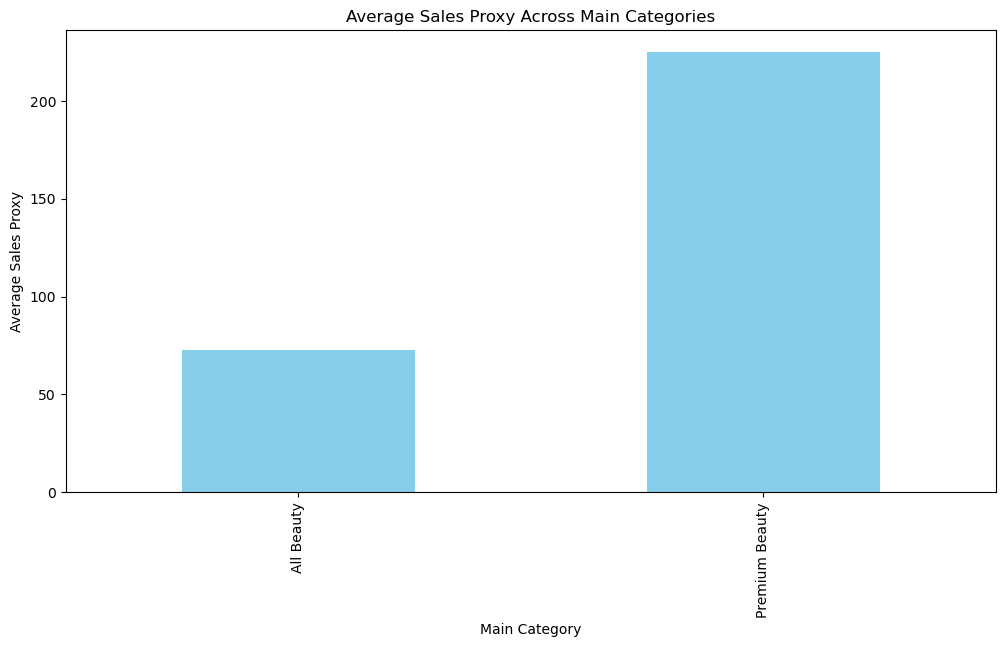

In [140]:
plt.figure(figsize=(12,6))
df1.groupby('main_category')['Rating_number(Sales_Proxy)'].mean().sort_values().plot(
    kind='bar', color='skyblue'
)
plt.title("Average Sales Proxy Across Main Categories")
plt.xlabel("Main Category")
plt.ylabel("Average Sales Proxy")
plt.xticks(rotation=90)
plt.show()

## 6. Correlation Heat Map

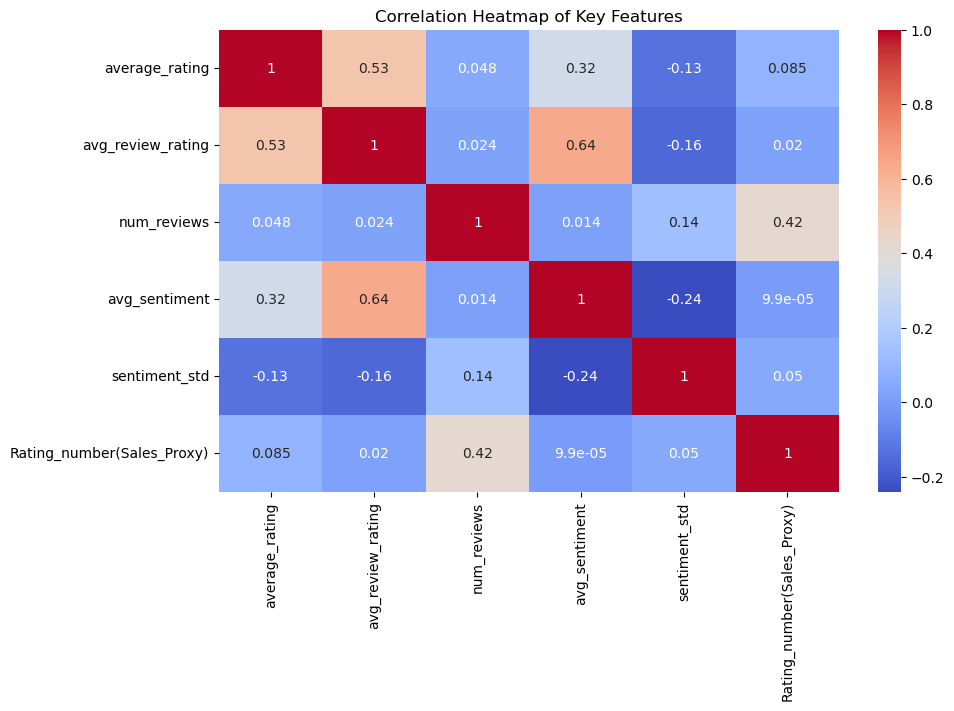

In [143]:
plt.figure(figsize=(10,6))
sns.heatmap(df1[['average_rating','avg_review_rating','num_reviews',
                      'avg_sentiment','sentiment_std',
                      'Rating_number(Sales_Proxy)']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Key Features")
plt.show()

# 7.Top 10 stores

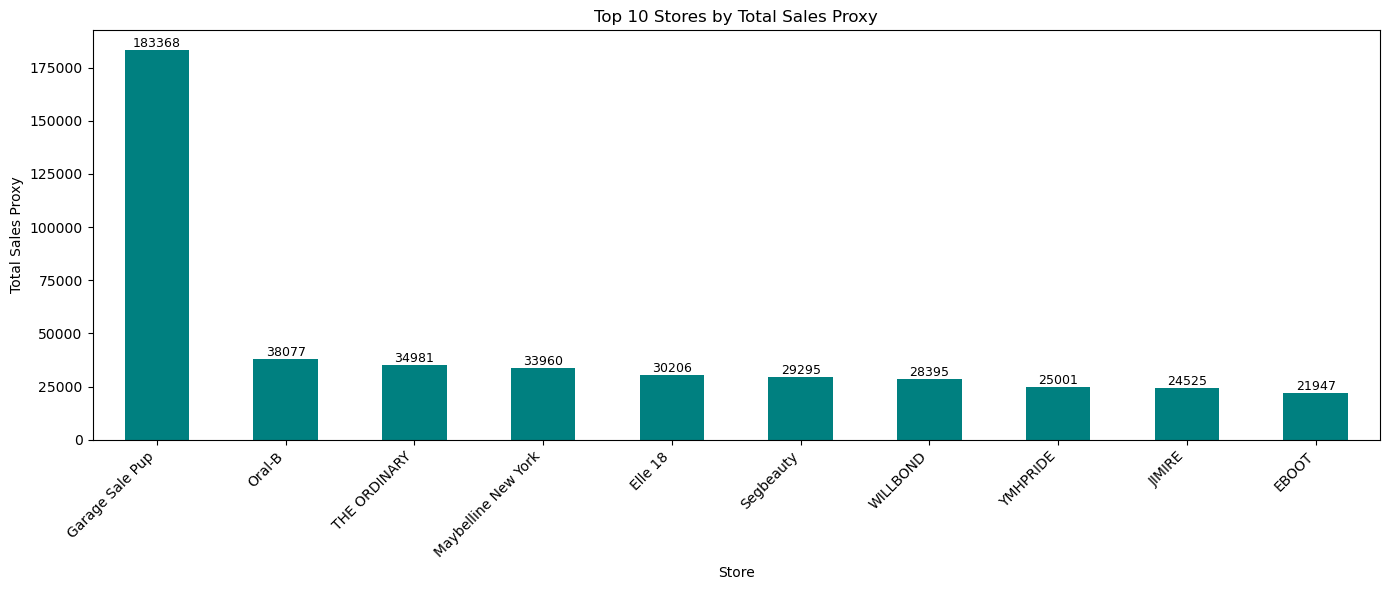

In [146]:
# Remove Unknown store rows
df_clean = df1[df1['store'] != 'Unknown']

# Compute top 10 stores by total sales proxy
top10_stores = (
    df_clean.groupby('store')['Rating_number(Sales_Proxy)']
            .sum()
            .sort_values(ascending=False)
            .head(10)
)

plt.figure(figsize=(14,6))
ax = top10_stores.plot(kind='bar', color='teal')

# Add values on top of bars
for i, v in enumerate(top10_stores):
    plt.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

plt.title("Top 10 Stores by Total Sales Proxy")
plt.xlabel("Store")
plt.ylabel("Total Sales Proxy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Encode categorical variables

In [149]:
final_df['main_category'].unique()

array(['All Beauty', 'Premium Beauty'], dtype=object)

In [151]:
from sklearn.preprocessing import LabelEncoder

for col in ['main_category', 'store']:
    le = LabelEncoder()
    final_df[col] = le.fit_transform(final_df[col].astype(str))

## Prepare features and target

In [154]:
w2v_cols = [f"w2v_{i}_mean" for i in range(100)]

In [156]:
# Log-transform target (correct column name)
final_df['sales_proxy_log'] = np.log1p(final_df['Rating_number(Sales_Proxy)'])

# Feature columns (metadata + review features + w2v)
feature_cols = [
    'main_category',
    'store',
    'average_rating',
    'avg_review_rating',
    'num_reviews',
    'avg_sentiment',
    'sentiment_std'
] + w2v_cols

# Feature matrix and target
X = final_df[feature_cols]
y = final_df['sales_proxy_log']

# Using Regression Models

#  Train–test split

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [162]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [164]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_rmse = mean_squared_error(y_test, baseline_pred, squared=False)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("=== Baseline: Mean Predictor ===")
print("RMSE:", baseline_rmse)
print("MAE :", baseline_mae)
print("R²  :", baseline_r2)
print("--------------------------------")

=== Baseline: Mean Predictor ===
RMSE: 1.15634427543977
MAE : 0.9133697920192038
R²  : -0.0003312065024447808
--------------------------------


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [168]:
from sklearn.linear_model import LinearRegression

meta_features = ['average_rating', 'main_category', 'store']

X_train_meta = X_train[meta_features]
X_test_meta = X_test[meta_features]

lr_meta = LinearRegression()
lr_meta.fit(X_train_meta, y_train)

meta_pred = lr_meta.predict(X_test_meta)

meta_rmse = np.sqrt(mean_squared_error(y_test, meta_pred))
meta_mae = mean_absolute_error(y_test, meta_pred)
meta_r2 = r2_score(y_test, meta_pred)

print("Metadata-Only Linear Regression")
print("RMSE:", meta_rmse)
print("MAE :", meta_mae)
print("R2  :", meta_r2)
print("-" * 40)

Metadata-Only Linear Regression
RMSE: 1.1376327350443773
MAE : 0.8937543003480048
R2  : 0.03178084935857639
----------------------------------------


In [170]:
sent_features = ['avg_sentiment', 'sentiment_std', 'num_reviews']

X_train_sent = X_train[sent_features]
X_test_sent = X_test[sent_features]

lr_sent = LinearRegression()
lr_sent.fit(X_train_sent, y_train)

sent_pred = lr_sent.predict(X_test_sent)

sent_rmse = np.sqrt(mean_squared_error(y_test, sent_pred))
sent_mae = mean_absolute_error(y_test, sent_pred)
sent_r2 = r2_score(y_test, sent_pred)

print("Sentiment-Only Linear Regression")
print("RMSE:", sent_rmse)
print("MAE :", sent_mae)
print("R2  :", sent_r2)
print("-" * 40)

Sentiment-Only Linear Regression
RMSE: 1.0181460069738775
MAE : 0.7966984980963778
R2  : 0.22448601738943152
----------------------------------------


In [172]:
# Define Models

In [174]:

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


In [176]:
# Train and Eavaluate Models

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, pred, squared=False)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    results.append([name, rmse, mae, r2])


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [177]:
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R²"])
print(results_df)


               Model      RMSE       MAE        R²
0  Linear Regression  0.987964  0.766637  0.269783
1      Random Forest  0.800688  0.597840  0.520382
2            XGBoost  0.773036  0.569366  0.552937


# Also Applying Classification Models on it to compare which algo are best training

In [180]:
df2 =final_df.copy()

In [182]:
df2 = df2.drop(columns=['store'])

In [184]:
df2['sales_class'] = pd.qcut(
    df2['Rating_number(Sales_Proxy)'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [186]:
df_model = df2[[
    'average_rating',
    'avg_review_rating',
    'num_reviews',
    'avg_sentiment',
    'sentiment_std',
    'main_category',
    'sales_class'
] + [col for col in df2.columns if col.startswith('w2v_')]]

In [188]:
df_model = pd.get_dummies(df_model, columns=['main_category'], drop_first=True)

In [190]:
from sklearn.model_selection import train_test_split

X = df_model.drop('sales_class', axis=1)
y = df_model['sales_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [192]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Baseline: Majority Class Classifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print("\n===== Baseline: Majority Class =====")
print("Accuracy:", accuracy_score(y_test, dummy_preds))
print("Precision:", precision_score(y_test, dummy_preds, average='weighted'))
print("Recall:", recall_score(y_test, dummy_preds, average='weighted'))
print("F1 Score:", f1_score(y_test, dummy_preds, average='weighted'))


===== Baseline: Majority Class =====
Accuracy: 0.34165029469548136
Precision: 0.11672492386550924
Recall: 0.34165029469548136
F1 Score: 0.17400200980390745


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [194]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)



In [196]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, average='weighted'))
    print("Recall:", recall_score(y_test, preds, average='weighted'))
    print("F1 Score:", f1_score(y_test, preds, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


===== Logistic Regression =====
Accuracy: 0.5596594629993451
Precision: 0.5627554636209323
Recall: 0.5596594629993451
F1 Score: 0.5488366564570167

Classification Report:
               precision    recall  f1-score   support

        High       0.72      0.60      0.65      5011
         Low       0.53      0.76      0.62      5217
      Medium       0.44      0.32      0.37      5042

    accuracy                           0.56     15270
   macro avg       0.56      0.56      0.55     15270
weighted avg       0.56      0.56      0.55     15270



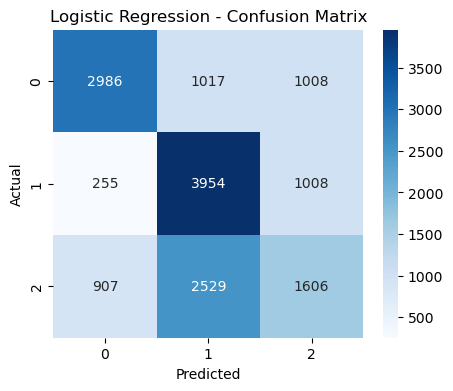

In [198]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=500)
evaluate(log_reg, "Logistic Regression")



===== Random Forest Classifier =====
Accuracy: 0.5738703339882122
Precision: 0.5829688159649344
Recall: 0.5738703339882122
F1 Score: 0.5678881856723307

Classification Report:
               precision    recall  f1-score   support

        High       0.75      0.59      0.66      5011
         Low       0.55      0.76      0.63      5217
      Medium       0.45      0.37      0.40      5042

    accuracy                           0.57     15270
   macro avg       0.58      0.57      0.57     15270
weighted avg       0.58      0.57      0.57     15270



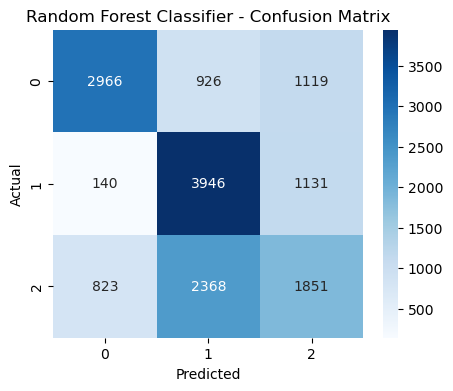

In [199]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
evaluate(rf, "Random Forest Classifier")